ques 1--> part1--> 1.
We initialize the random seed using the roll number to ensure reproducibility of results. This ensures that each student generates unique but consistent data.

In [2]:


import numpy as np
import pandas as pd

roll_number =110

np.random.seed(roll_number)

2. A NumPy array of shape (12,4) is generated to represent monthly sales data for four product categories. The values range between 1000 and 5000 units.

In [3]:
sales_data = np.random.randint(1000, 5000, size=(12, 4))
sales_data

array([[3176, 2763, 3109, 2295],
       [3429, 2881, 1431, 3944],
       [3000, 3256, 2862, 4938],
       [3299, 2288, 3793, 2669],
       [2440, 4793, 2787, 2505],
       [1510, 2136, 2000, 2767],
       [2260, 1732, 2946, 2705],
       [3474, 1279, 4969, 2022],
       [4394, 3937, 3513, 1661],
       [1543, 4818, 1432, 1389],
       [1213, 4746, 4202, 4123],
       [1838, 2924, 2472, 4271]])

3. The NumPy array is converted into a Pandas DataFrame with appropriate column names representing product categories and index labels representing months from January to December.

In [4]:
columns = ["Electronics", "Clothing", "Home & Kitchen", "Sports"]

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

df = pd.DataFrame(sales_data, columns=columns, index=months)

df

,Electronics,Clothing,Home & Kitchen,Sports
Jan,3176,2763,3109,2295
Feb,3429,2881,1431,3944
Mar,3000,3256,2862,4938
Apr,3299,2288,3793,2669
May,2440,4793,2787,2505
Jun,1510,2136,2000,2767
Jul,2260,1732,2946,2705
Aug,3474,1279,4969,2022
Sep,4394,3937,3513,1661
Oct,1543,4818,1432,1389


part 2--> 1. The first 5 rows of the dataset are displayed using head(). Summary statistics such as mean, standard deviation, minimum and maximum values are computed using describe().

In [8]:
# First 5 rows
df.head()

,Electronics,Clothing,Home & Kitchen,Sports
Jan,3176,2763,3109,2295
Feb,3429,2881,1431,3944
Mar,3000,3256,2862,4938
Apr,3299,2288,3793,2669
May,2440,4793,2787,2505


In [9]:
# Summary statistics
df.describe()

,Electronics,Clothing,Home & Kitchen,Sports
count,12.000000,12.000000,12.000000,12.000000
mean,2631.333333,3129.416667,2959.666667,2940.750000
std,981.145465,1213.942522,1064.836337,1120.838738
min,1213.000000,1279.000000,1431.000000,1389.000000
25%,1764.250000,2250.000000,2354.000000,2226.750000
50%,2720.000000,2902.500000,2904.000000,2687.000000
75%,3331.500000,4139.250000,3583.000000,3988.750000
max,4394.000000,4818.000000,4969.000000,4938.000000


2. Total sales per category are calculated by summing each column. Total sales per month are calculated by summing each row.

In [10]:
# Total sales per category
category_total = df.sum(axis=0)
category_total

# Total sales per month
monthly_total = df.sum(axis=1)
monthly_total

,0
Jan,11343
Feb,11685
Mar,14056
Apr,12049
May,12525
Jun,8413
Jul,9643
Aug,11744
Sep,13505
Oct,9182


3.Total sales per category are calculated by summing each column. Total sales per month are calculated by summing each row.

In [11]:
# Percentage growth per category
growth = df.pct_change()

# Average growth per category
avg_growth = growth.mean()
avg_growth

,0
Electronics,0.033083
Clothing,0.169863
Home & Kitchen,0.184993
Sports,0.176474


4. A new column “Total Sales” is added by summing all category values for each month. Another column “Growth Rate” is added to represent the percentage change in total sales compared to the previous month.

In [12]:
df["Total Sales"] = df.sum(axis=1)
df["Growth Rate"] = df["Total Sales"].pct_change() * 100

5. A conditional discount is applied based on the roll number. If the roll number is even, a 10% discount is applied to Electronics. If odd, a 15% discount is applied to Clothing.

In [13]:
roll_number = 123  # change this

if roll_number % 2 == 0:
    df["Electronics"] = df["Electronics"] * 0.90
    print("10% discount applied to Electronics")
else:
    df["Clothing"] = df["Clothing"] * 0.85
    print("15% discount applied to Clothing")

df

15% discount applied to Clothing


,Electronics,Clothing,Home & Kitchen,Sports,Total Sales,Growth Rate
Jan,3176,2348.55,3109,2295,11343,NaN
Feb,3429,2448.85,1431,3944,11685,3.015075
Mar,3000,2767.60,2862,4938,14056,20.290971
Apr,3299,1944.80,3793,2669,12049,-14.278600
May,2440,4074.05,2787,2505,12525,3.950535
Jun,1510,1815.60,2000,2767,8413,-32.830339
Jul,2260,1472.20,2946,2705,9643,14.620231
Aug,3474,1087.15,4969,2022,11744,21.787825
Sep,4394,3346.45,3513,1661,13505,14.994891
Oct,1543,4095.30,1432,1389,9182,-32.010367


part 3

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# for better visuals
sns.set(style="whitegrid")

1. A line plot is used to visualize monthly sales trends for each product category. Each line represents a category, allowing comparison of how sales vary over time. This helps identify seasonal patterns and growth trends.

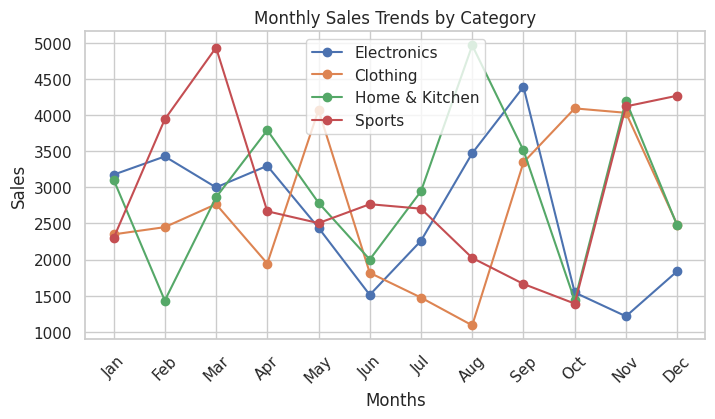

In [16]:
plt.figure(figsize=(8,4))

for column in ["Electronics", "Clothing", "Home & Kitchen", "Sports"]:
    plt.plot(df.index, df[column], marker='o', label=column)

plt.title("Monthly Sales Trends by Category")
plt.xlabel("Months")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)

plt.show()

2. A line plot is used to visualize monthly sales trends for each product category. Each line represents a category, allowing comparison of how sales vary over time. This helps identify seasonal patterns and growth trends.

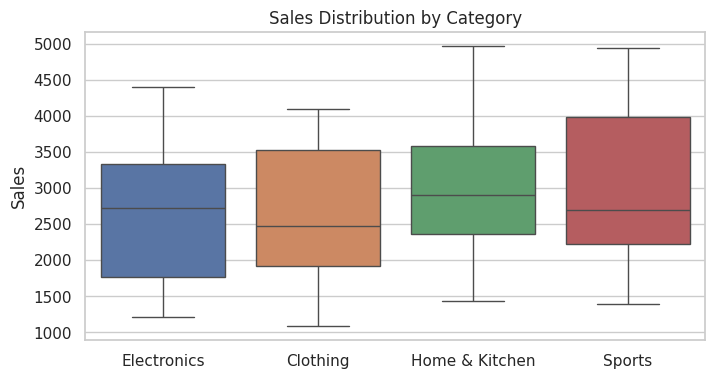

In [18]:
plt.figure(figsize=(8,4))

sns.boxplot(data=df[["Electronics", "Clothing", "Home & Kitchen", "Sports"]])

plt.title("Sales Distribution by Category")
plt.ylabel("Sales")

plt.show()

ques 2-->

In [19]:
import numpy as np

array = np.array([[1, -2, 3],
                  [-4, 5, -6]])

1. The absolute value of each element is computed using np.abs(), converting all negative values into positive values.

In [20]:
abs_array = np.abs(array)
abs_array

array([[1, 2, 3],
       [4, 5, 6]])

2.Percentiles (25th, 50th, and 75th) are calculated using np.percentile() for the flattened array, as well as across rows and columns to understand data distribution.
 a. flattened array

In [21]:
flat = array.flatten()

percentiles_flat = np.percentile(flat, [25, 50, 75])
percentiles_flat

array([-3.5, -0.5,  2.5])

b. column wise

In [22]:
percentiles_col = np.percentile(array, [25, 50, 75], axis=0)
percentiles_col

array([[-2.75, -0.25, -3.75],
       [-1.5 ,  1.5 , -1.5 ],
       [-0.25,  3.25,  0.75]])

c. row wise

In [23]:
percentiles_row = np.percentile(array, [25, 50, 75], axis=1)
percentiles_row

array([[-0.5, -5. ],
       [ 1. , -4. ],
       [ 2. ,  0.5]])

3. Mean, median, and standard deviation are computed for the flattened array, as well as along rows and columns. These statistical measures help summarize the central tendency and variability of the data.
a. flattened array

In [29]:
print("\n(iii) Flattened Array Stats:")
print("Mean:", np.mean(flat))
print("Median:", np.median(flat))
print("Standard Deviation:", np.std(flat))


(iii) Flattened Array Stats:
Mean: -0.5
Median: -0.5
Standard Deviation: 3.8622100754188224


b. column wise

In [28]:
print("\nRow-wise Stats:")
print("Mean:", np.mean(array, axis=1))
print("Median:", np.median(array, axis=1))
print("Standard Deviation:", np.std(array, axis=1))


Row-wise Stats:
Mean: [ 0.66666667 -1.66666667]
Median: [ 1. -4.]
Standard Deviation: [2.05480467 4.78423336]


c. row wise

In [27]:
print("\nRow-wise Stats:")
print("Mean:", np.mean(array, axis=1))
print("Median:", np.median(array, axis=1))
print("Standard Deviation:", np.std(array, axis=1))
#axis=0 → column-wise
#axis=1 → row-wise
#flatten() → 1D array


Row-wise Stats:
Mean: [ 0.66666667 -1.66666667]
Median: [ 1. -4.]
Standard Deviation: [2.05480467 4.78423336]


ques 3--> Floor values are the largest integers less than or equal to the elements. Ceiling values are the smallest integers greater than or equal to the elements. Truncated values remove the decimal part, moving towards zero. Rounded values represent the nearest integer, following standard rounding rules.

In [30]:
import numpy as np

a = np.array([-1.8, -1.6, -0.5, 0.5, 1.6, 1.8, 3.0])

In [31]:
floor_vals = np.floor(a)
print("Floor values:", floor_vals)

Floor values: [-2. -2. -1.  0.  1.  1.  3.]


In [32]:
ceil_vals = np.ceil(a)
print("Ceiling values:", ceil_vals)

Ceiling values: [-1. -1. -0.  1.  2.  2.  3.]


In [33]:
trunc_vals = np.trunc(a)
print("Truncated values:", trunc_vals)

#Difference between floor & trunc (very commonly asked):

#Floor → goes down (towards -∞)
#Trunc → goes toward 0

Truncated values: [-1. -1. -0.  0.  1.  1.  3.]


In [34]:
round_vals = np.round(a)
print("Rounded values:", round_vals)

Rounded values: [-2. -2. -0.  0.  2.  2.  3.]


ques 4--> Two elements of the list are swapped using a temporary variable. First, the value at the first position is stored in a temporary variable. Then the value at the second position is assigned to the first position. Finally, the temporary value is assigned to the second position, completing the swap.

In [35]:
# Given list
lst = [10, 20, 30, 40]

print("Original List:", lst)

# Positions to swap
pos1 = 1   # index of 20
pos2 = 3   # index of 40

# Swapping using temporary variable
temp = lst[pos1]
lst[pos1] = lst[pos2]
lst[pos2] = temp

print("List after swapping:", lst)

Original List: [10, 20, 30, 40]
List after swapping: [10, 40, 30, 20]


ques 5--> Sets in Python are unordered collections, so elements cannot be accessed or swapped directly using indexing. Therefore, the set is first converted into a list. The elements are then swapped using a temporary variable, and finally, the list is converted back into a set.

In [36]:
# Given set
s = {10, 20, 30, 40}

print("Original Set:", s)

# Convert set to list
lst = list(s)

# Positions to swap
pos1 = 1
pos2 = 3

# Swapping using temporary variable
temp = lst[pos1]
lst[pos1] = lst[pos2]
lst[pos2] = temp

# Convert back to set
s = set(lst)

print("Set after swapping:", s)

Original Set: {40, 10, 20, 30}
Set after swapping: {40, 10, 20, 30}
